In [1]:
import os
import sys
import numpy as np
import swyft
import pickle
import matplotlib.pyplot as plt
import torch
import importlib
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor
torch.set_float32_matmul_precision('medium')
device_notebook = "cuda" if torch.cuda.is_available() else "cpu"
import wandb
import copy
from torch.multiprocessing import Pool
torch.multiprocessing.set_start_method('spawn',force=True)
torch.set_num_threads(28)
import itertools
import subprocess
from tqdm.auto import tqdm
sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
from explim_functions import generate_expected_limits
from scipy.integrate import trapz

In [2]:
main_dir = "ALPs_with_SWYFT"
thesis_figs = os.getcwd().split(main_dir)[0]+"/"+main_dir+"/thesis_figures/"

In [3]:
names = ['flare0_agnostic', 'flare0_semi_informed', 'flare0_informed','flare0_confident1','flare0_confident3']
titles = ["Agnostic Prior", "Semi-Informed Prior", "Informed Prior", "Confident Prior", "CTAO Prior"]
xlabel = "ALP mass ($m_\mathrm{a}$) / $\mathrm{neV}$"
ylabel = "Photon-ALP coupling ($g_{\mathrm{a}\gamma}$) / $10^{-11} \mathrm{GeV}^{-1}$"
colors_priors = ['r','#FFA500','y','g','b', ]

In [4]:
priors = {}
for ip, name in enumerate(names):

    priors[name] = {'name': name}

    priors[name]['results_path'] = '/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/'+name

    priors[name]['store_path'] = priors[name]['results_path']+"/sim_output/store"

    priors[name]['config_vars'] = priors[name]['results_path'] +'/config_variables.pickle'

    priors[name]['config_phys'] = priors[name]['results_path'] +'/physics_variables.pickle'
    
    priors[name]['truncation_record'] = priors[name]['results_path'] +'/truncation_record.pickle'

    removed_ALP_sim=0
    try:
        sys.path.remove('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
        removed_ALP_sim=1
    except ValueError:
        pass
    try:
        del sys.modules['ALP_quick_sim']
    except KeyError:
        pass
    sys.path.append(priors[name]['results_path'])
    import param_function
    import ALP_quick_sim
    import alp_swyft_simulator 
    ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator
    with open(priors[name]['config_vars'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['config_phys'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['truncation_record'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    sys.path.remove(priors[name]['results_path'])
    sys.path.append(priors[name]['results_path']+'/train_output/net')
    import network
    sys.path.remove(priors[name]['results_path']+'/train_output/net')
    
    count = 0
    for combo in itertools.product(*priors[name]['hyperparams'].values()):
        if count == priors[name]['which_grid_point']:
            hyperparams_point = {}
            for i, key in enumerate(priors[name]['hyperparams'].keys()):
                hyperparams_point[key]=combo[i]
        count +=1
        
    priors[name]['net_path'] = (priors[name]['results_path'] + '/train_output/net/trained_network_round_'
                                +str(priors[name]['which_truncation'])+'_gridpoint_'+str(priors[name]['which_grid_point'])+'.pt')

    priors[name]['net'] = network.NetworkCorner(nbins=priors[name]['A'].nbins, marginals=priors[name]['POI_indices'], 
                                                param_names=priors[name]['A'].param_names, **hyperparams_point)

    priors[name]['net'].load_state_dict(torch.load(priors[name]['net_path']))

    explim_allspect_bounds = copy.copy(priors[name]['bounds_rounds'][0][-2])
    explim_allspect_bounds[0] = [-6,-6]
    explim_allspect_bounds[1] = [-5,-5]
    priors[name]['explim_allspect_sim'] = ALP_SWYFT_Simulator(priors[name]['A'], explim_allspect_bounds, priors[name]['prior_funcs'])

    # with open(priors[name]['results_path']+'/explim_predictions.pickle', 'rb') as file:
    #     priors[name]['predictions'] = pickle.load(file)
    
    if priors[name]['which_truncation'] > 0:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_explim_allspect = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_allspect_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        # store_train = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
    else:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim")
        store_explim_allspect = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_allspect")
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior")
        # store_train = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name'])
    priors[name]['samples_explim'] = store_explim.get_sample_store()
    priors[name]['samples_prior'] = store_prior.get_sample_store()
    # priors[name]['samples_train'] = store_train.get_sample_store()
    try:
        priors[name]['samples_explim_allspect'] = store_explim_allspect.get_sample_store()
    except:
        sands = priors[name]['explim_allspect_sim'].get_shapes_and_dtypes()
        store_explim_allspect.init(
            N = 1000,
            chunk_size = 1000,
            shapes=sands[0],
            dtypes=sands[1],
        )
        store_explim_allspect.simulate(priors[name]['explim_allspect_sim'],batch_size = 1000)
        priors[name]['samples_explim_allspect'] = store_explim_allspect.get_sample_store()

    del sys.modules['param_function']
    del sys.modules['ALP_quick_sim']
    del sys.modules['alp_swyft_simulator']
    del sys.modules['network']
    if removed_ALP_sim: sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packag

/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/flare0_agnostic/ALP_quick_sim.py:474: UserWarning: The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal
  warnings.warn("The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal")


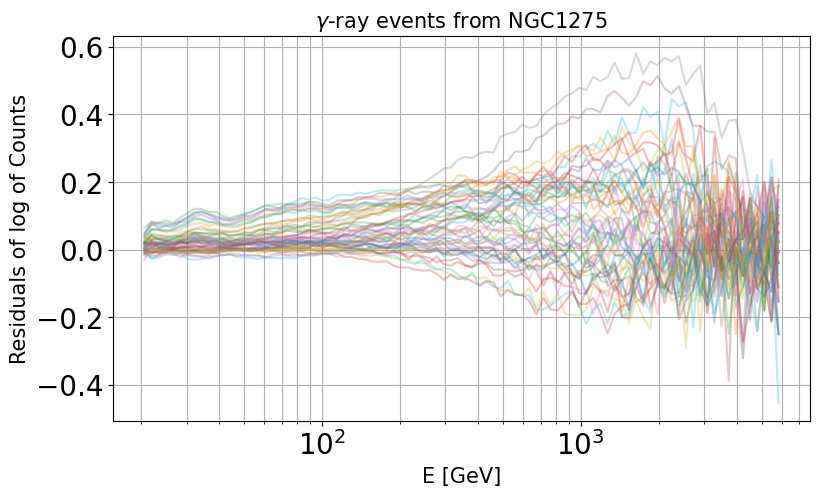

In [5]:
name = 'flare0_agnostic'

A = priors[name]['A']

samples = priors[name]['samples_explim_allspect']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
# A.configure_plot(xmin=2e1, xmax=1e3, ymin=-0.05,ymax=0.05,legend=0, logx=1, logy=0)
for i in range(min(len(samples),50)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)

In [6]:
trainer = swyft.SwyftTrainer(accelerator = 'cuda', precision = 64,logger=False,)

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [7]:
contour_matrices = {}
exclusion_areas = {}
predictionss = {}

In [8]:
# del sys.modules['explim_functions']
# from explim_functions import generate_expected_limits

In [9]:
colors=['b','g','y','#FFA500','r','k']
line_colors=['b','g','#FFA500','r','b']
linestyles = [':','-.','--','-','-']

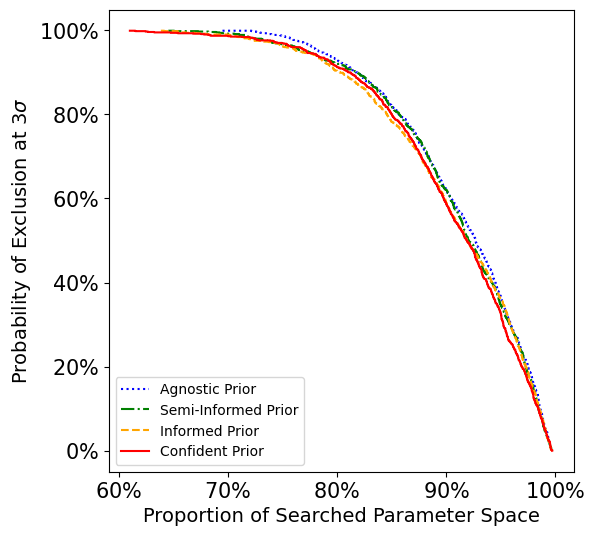

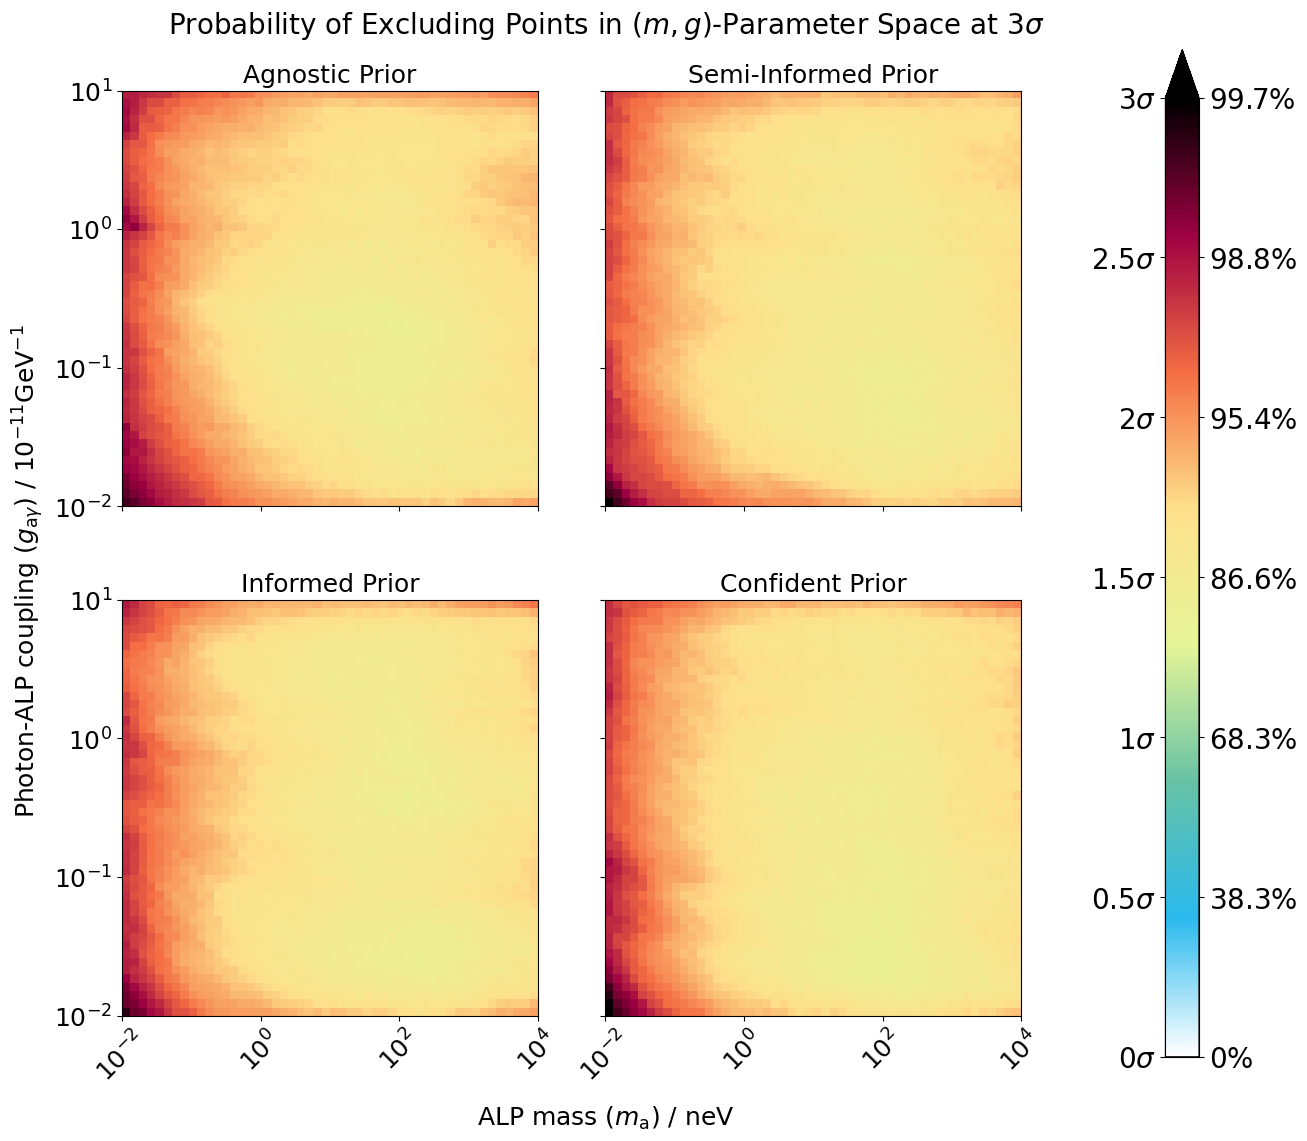

In [12]:
# contour_matrices['flare0_agnostic'] = None
# priors['flare0_agnostic']['predictions'] = None

# colors=['r','#FFA500','y','g','b','k']
if __name__ == "__main__":
    figh = plt.figure(figsize=(6,6))
    figh.add_subplot(1,1,1)
    fig, axes = plt.subplots(2,2,figsize=(12,11.3))
    for i in range(4):
        
        name = names[i]
        
        try:
            contour_matrix = contour_matrices[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/contour_matrix-'+name+'_allspect.pickle', 'rb') as file: contour_matrix = pickle.load(file)
            except FileNotFoundError:
                contour_matrix = None
        try:
            exclusion_area = exclusion_areas[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/exclusion_areas-'+name+'_allspect.pickle', 'rb') as file: exclusion_area = pickle.load(file)
            except FileNotFoundError:
                exclusion_area = None
        try:
            predictions = predictionss[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/explim_predictions-'+name+'_allspect.pickle', 'rb') as file: predictions = pickle.load(file)
            except FileNotFoundError:
                predictions = None
        
        # fig.add_subplot(2,2,i+1)
        # fig.axes[-1].set_title(name)
        fig.axes[i].set_title(name)
        contour_matrix,exclusion_area,_,_ = generate_expected_limits(
            priors[name]['samples_explim_allspect'],
            priors[name]['samples_prior'],
            bounds = [priors[name]['bounds'][0], priors[name]['bounds'][1]],
            predictions=predictions,
            ax=fig.axes[i],
            levels = None,
            max_level = 3,
            contour_matrix=contour_matrix,
            exclusion_areas=exclusion_area,
            colors=colors,
            alpha_variable=False,
            n_cores = 4,
            trainer=trainer,
            net=priors[name]['net']
        )

        axis_ticksize = 18
        fig.axes[i].set_yticks([-2,-1,0,1])
        fig.axes[i].set_xticks([-2,0,2,4])
        if i in [0,2]:
            fig.axes[i].set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=axis_ticksize)
        else:
            fig.axes[i].set_yticklabels(['','','',''])
        if i in [2,3]:    
            fig.axes[i].set_xticklabels(['$10^{-2}$','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=axis_ticksize)
        else:
            fig.axes[i].set_xticklabels(['','','',''])

        fig.axes[i].set_title(titles[i],fontsize = 18)

        contour_matrices[name] = contour_matrix
        exclusion_areas[name] = exclusion_area
        predictionss[name] = predictions
        with open(os.getcwd()+'/contour_matrix-'+name+'_allspect.pickle','wb') as file: pickle.dump(contour_matrix, file)
        with open(os.getcwd()+'/exclusion_areas-'+name+'_allspect.pickle','wb') as file: pickle.dump(exclusion_area, file)
        with open(os.getcwd()+'/explim_predictions-'+name+'_allspect.pickle', 'wb') as file: pickle.dump(predictions, file)
        
        h,alpha = np.histogram(exclusion_area, bins=50*50+1)
        figh.axes[-1].plot(alpha[:-1],1-np.cumsum(h)/len(priors[name]['samples_explim']), color=line_colors[i], linestyle=linestyles[i],label=titles[i])

    
    figh.axes[-1].legend()
    figh.axes[-1].set_xlabel('Proportion of Searched Parameter Space', fontsize=14)
    figh.axes[-1].set_ylabel('Probability of Exclusion at $3\sigma$', fontsize=14)
    figh.axes[-1].set_xticks(figh.axes[-1].get_xticks()[1:-1])
    figh.axes[-1].set_xticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[-1].get_xticks()]),fontsize=15)
    figh.axes[-1].set_yticks(figh.axes[-1].get_yticks()[1:-1])
    figh.axes[-1].set_yticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[-1].get_yticks()]),fontsize=15)

    cbar = fig.colorbar(fig.axes[-1].get_images()[0],ax=fig.axes, extend='max', aspect=30)
    cbar.ax.set_yticks([0,0.5,1,1.5,2,2.5,3])
    cbar.ax.set_yticklabels(['$0\sigma$','$0.5\sigma$','$1\sigma$','$1.5\sigma$','$2\sigma$','$2.5\sigma$','$3\sigma$'])
    cbar_twin = cbar.ax.twinx()
    cbar_twin.set_yticks([0,0.5,1,1.5,2,2.5,3])
    cbar_twin.set_yticklabels(['$0\%$','$38.3\%$','$68.3\%$','$86.6\%$','$95.4\%$','$98.8\%$','$99.7\%$'])

    axislabel_fontsize = 18
    fig.supxlabel(xlabel,fontsize=axislabel_fontsize)
    fig.supylabel(ylabel,fontsize=axislabel_fontsize)
    fig.suptitle("Probability of Excluding Points in $(m,g)$-Parameter Space at $3\sigma$ ", fontsize=20)
    
    fig.set_constrained_layout(True)

In [14]:
predictionss

{'flare0_agnostic': None,
 'flare0_semi_informed': None,
 'flare0_informed': None,
 'flare0_confident1': None}

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/pytorch_lightning/loops/epoch/prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")
100%|██████████| 250/250 [56:54<00:00, 13.66s/it]
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

100%|██████████| 250/250 [56:41<00:00, 13.61s/it]
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

100%|██████████| 250/250 [36:16<00:00,  8.70s/it]
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

100%|██████████| 250/250 [38:56<00:00,  9.35s/it]


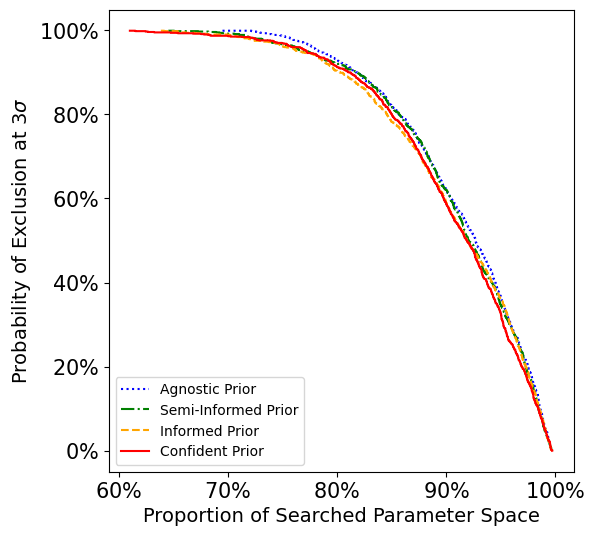

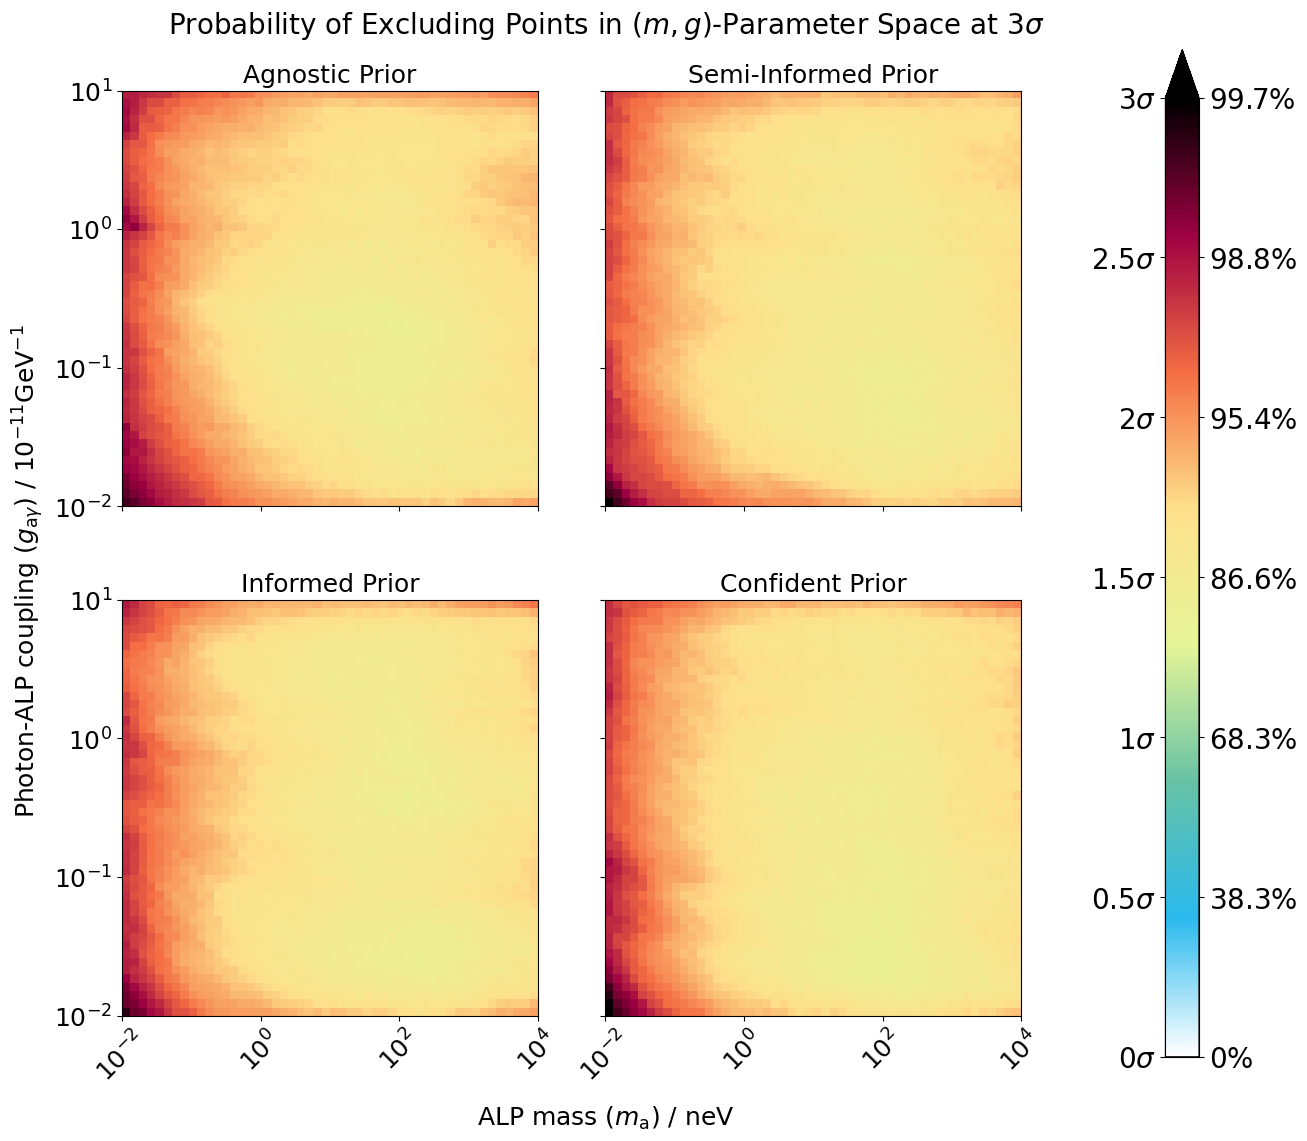

In [10]:
if __name__ == "__main__":
    figh = plt.figure(figsize=(6,6))
    figh.add_subplot(1,1,1)
    fig, axes = plt.subplots(2,2,figsize=(12,11.3))
    for i in range(4):
        
        name = names[i]
        
        try:
            contour_matrix = contour_matrices[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/contour_matrix-'+name+'_allspect.pickle', 'rb') as file: contour_matrix = pickle.load(file)
            except FileNotFoundError:
                contour_matrix = None
        try:
            exclusion_area = exclusion_areas[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/exclusion_areas-'+name+'_allspect.pickle', 'rb') as file: exclusion_area = pickle.load(file)
            except FileNotFoundError:
                exclusion_area = None
        try:
            predictions = predictionss[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/explim_predictions-'+name+'_allspect.pickle', 'rb') as file: predictions = pickle.load(file)
            except FileNotFoundError:
                predictions = None
        
        # fig.add_subplot(2,2,i+1)
        # fig.axes[-1].set_title(name)
        fig.axes[i].set_title(name)
        contour_matrix,exclusion_area,predictions,_ = generate_expected_limits(
            priors[name]['samples_explim_allspect'],
            priors[name]['samples_prior'],
            bounds = [priors[name]['bounds'][0], priors[name]['bounds'][1]],
            predictions=predictions,
            ax=fig.axes[i],
            levels = None,
            max_level = 3,
            contour_matrix=contour_matrix,
            exclusion_areas=exclusion_area,
            colors=colors,
            alpha_variable=False,
            n_cores = 4,
            trainer=trainer,
            net=priors[name]['net'],
            param_names = ['Amplitude','index']
        )

        axis_ticksize = 18
        fig.axes[i].set_yticks([-2,-1,0,1])
        fig.axes[i].set_xticks([-2,0,2,4])
        if i in [0,2]:
            fig.axes[i].set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=axis_ticksize)
        else:
            fig.axes[i].set_yticklabels(['','','',''])
        if i in [2,3]:    
            fig.axes[i].set_xticklabels(['$10^{-2}$','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=axis_ticksize)
        else:
            fig.axes[i].set_xticklabels(['','','',''])

        fig.axes[i].set_title(titles[i],fontsize = 18)

        contour_matrices[name] = contour_matrix
        exclusion_areas[name] = exclusion_area
        predictionss[name] = predictions
        with open(os.getcwd()+'/contour_matrix-'+name+'_allspect.pickle','wb') as file: pickle.dump(contour_matrix, file)
        with open(os.getcwd()+'/exclusion_areas-'+name+'_allspect.pickle','wb') as file: pickle.dump(exclusion_area, file)
        with open(os.getcwd()+'/explim_predictions-'+name+'_allspect.pickle', 'wb') as file: pickle.dump(predictions, file)
        
        h,alpha = np.histogram(exclusion_area, bins=50*50+1)
        figh.axes[-1].plot(alpha[:-1],1-np.cumsum(h)/len(priors[name]['samples_explim']), color=line_colors[i], linestyle=linestyles[i],label=titles[i])

    
    figh.axes[-1].legend()
    figh.axes[-1].set_xlabel('Proportion of Searched Parameter Space', fontsize=14)
    figh.axes[-1].set_ylabel('Probability of Exclusion at $3\sigma$', fontsize=14)
    figh.axes[-1].set_xticks(figh.axes[-1].get_xticks()[1:-1])
    figh.axes[-1].set_xticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[-1].get_xticks()]),fontsize=15)
    figh.axes[-1].set_yticks(figh.axes[-1].get_yticks()[1:-1])
    figh.axes[-1].set_yticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[-1].get_yticks()]),fontsize=15)

    cbar = fig.colorbar(fig.axes[-1].get_images()[0],ax=fig.axes, extend='max', aspect=30)
    cbar.ax.set_yticks([0,0.5,1,1.5,2,2.5,3])
    cbar.ax.set_yticklabels(['$0\sigma$','$0.5\sigma$','$1\sigma$','$1.5\sigma$','$2\sigma$','$2.5\sigma$','$3\sigma$'])
    cbar_twin = cbar.ax.twinx()
    cbar_twin.set_yticks([0,0.5,1,1.5,2,2.5,3])
    cbar_twin.set_yticklabels(['$0\%$','$38.3\%$','$68.3\%$','$86.6\%$','$95.4\%$','$98.8\%$','$99.7\%$'])

    axislabel_fontsize = 18
    fig.supxlabel(xlabel,fontsize=axislabel_fontsize)
    fig.supylabel(ylabel,fontsize=axislabel_fontsize)
    fig.suptitle("Probability of Excluding Points in $(m,g)$-Parameter Space at $3\sigma$ ", fontsize=20)
    
    fig.set_constrained_layout(True)

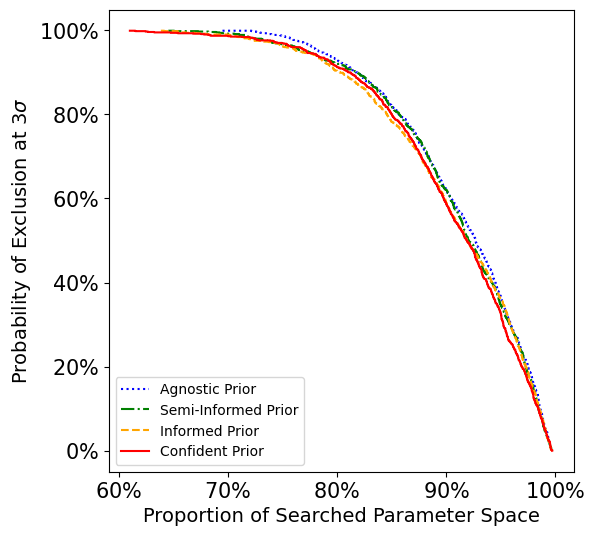

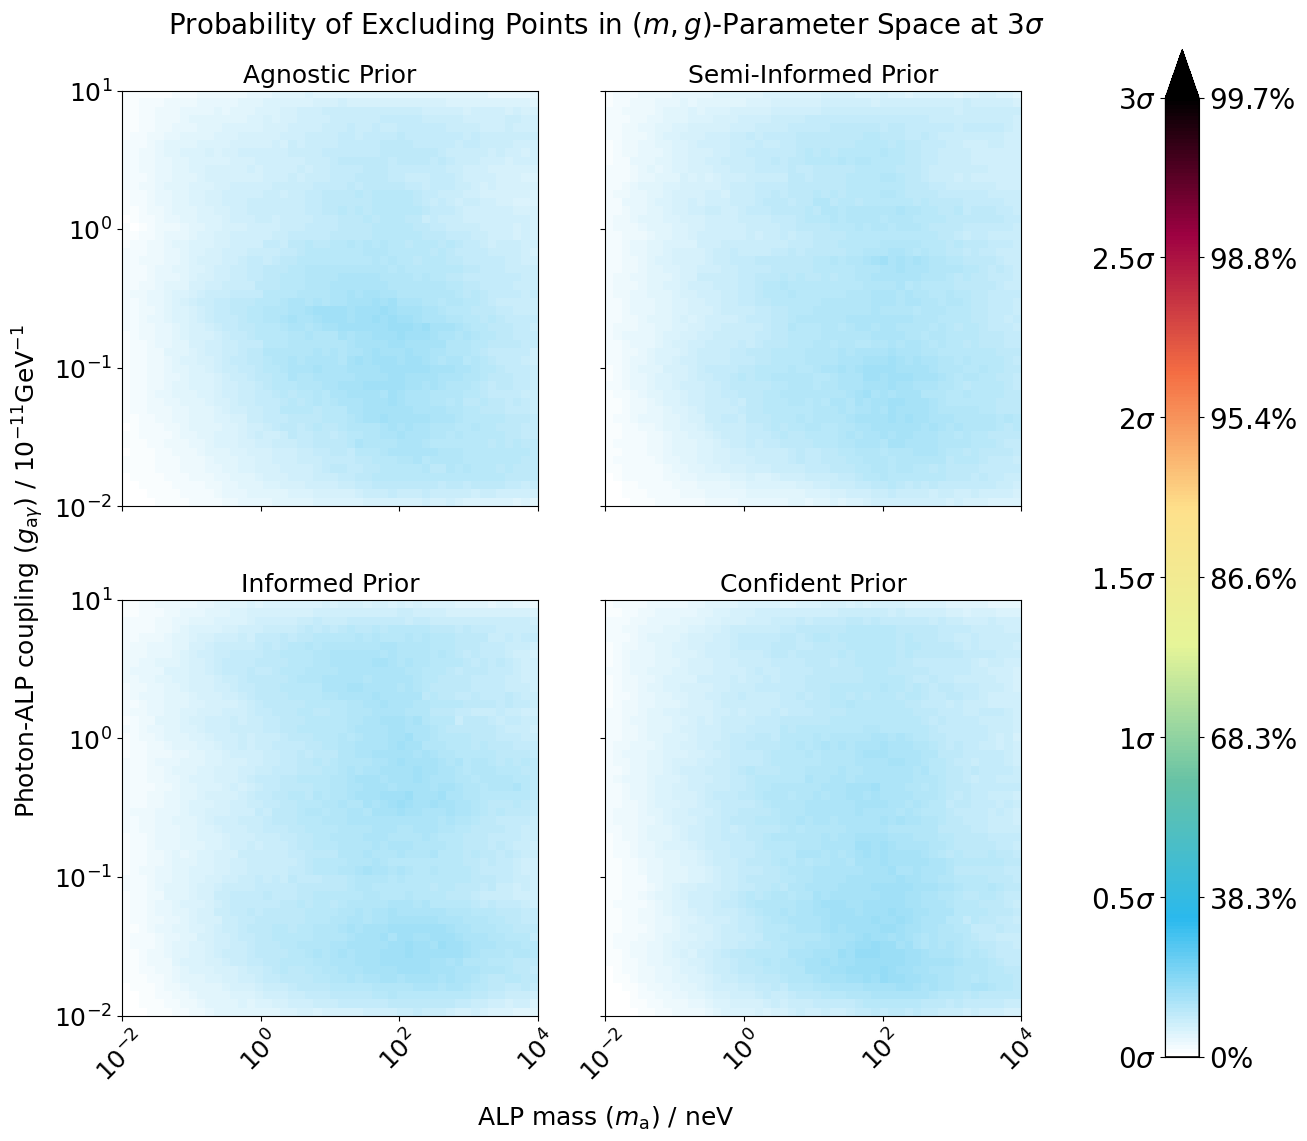

In [18]:
if __name__ == "__main__":
    figh = plt.figure(figsize=(6,6))
    figh.add_subplot(1,1,1)
    fig, axes = plt.subplots(2,2,figsize=(12,11.3))
    for i in range(4):
        
        name = names[i]
        
        try:
            contour_matrix = contour_matrices[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/contour_matrix-'+name+'_allspect.pickle', 'rb') as file: contour_matrix = pickle.load(file)
            except FileNotFoundError:
                contour_matrix = None
        try:
            exclusion_area = exclusion_areas[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/exclusion_areas-'+name+'_allspect.pickle', 'rb') as file: exclusion_area = pickle.load(file)
            except FileNotFoundError:
                exclusion_area = None
        try:
            predictions = predictionss[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/explim_predictions-'+name+'_allspect.pickle', 'rb') as file: predictions = pickle.load(file)
            except FileNotFoundError:
                predictions = None
        
        # fig.add_subplot(2,2,i+1)
        # fig.axes[-1].set_title(name)
        fig.axes[i].set_title(name)
        contour_matrix,exclusion_area,_,_ = generate_expected_limits(
            priors[name]['samples_explim_allspect'],
            priors[name]['samples_prior'],
            bounds = [priors[name]['bounds'][0], priors[name]['bounds'][1]],
            predictions=predictions,
            ax=fig.axes[i],
            levels = None,
            max_level = 3,
            contour_matrix=1000-contour_matrix,
            exclusion_areas=exclusion_area,
            colors=colors,
            alpha_variable=False,
            n_cores = 4,
            trainer=trainer,
            net=priors[name]['net'],
            param_names = ['Amplitude','Ecut']
        )

        axis_ticksize = 18
        fig.axes[i].set_yticks([-2,-1,0,1])
        fig.axes[i].set_xticks([-2,0,2,4])
        if i in [0,2]:
            fig.axes[i].set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=axis_ticksize)
        else:
            fig.axes[i].set_yticklabels(['','','',''])
        if i in [2,3]:    
            fig.axes[i].set_xticklabels(['$10^{-2}$','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=axis_ticksize)
        else:
            fig.axes[i].set_xticklabels(['','','',''])

        fig.axes[i].set_title(titles[i],fontsize = 18)

        contour_matrices[name] = contour_matrix
        exclusion_areas[name] = exclusion_area
        predictionss[name] = predictions
        with open(os.getcwd()+'/contour_matrix-'+name+'_allspect.pickle','wb') as file: pickle.dump(contour_matrix, file)
        with open(os.getcwd()+'/exclusion_areas-'+name+'_allspect.pickle','wb') as file: pickle.dump(exclusion_area, file)
        with open(os.getcwd()+'/explim_predictions-'+name+'_allspect.pickle', 'wb') as file: pickle.dump(predictions, file)
        
        h,alpha = np.histogram(exclusion_area, bins=50*50+1)
        figh.axes[-1].plot(alpha[:-1],1-np.cumsum(h)/len(priors[name]['samples_explim']), color=line_colors[i], linestyle=linestyles[i],label=titles[i])

    
    figh.axes[-1].legend()
    figh.axes[-1].set_xlabel('Proportion of Searched Parameter Space', fontsize=14)
    figh.axes[-1].set_ylabel('Probability of Exclusion at $3\sigma$', fontsize=14)
    figh.axes[-1].set_xticks(figh.axes[-1].get_xticks()[1:-1])
    figh.axes[-1].set_xticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[-1].get_xticks()]),fontsize=15)
    figh.axes[-1].set_yticks(figh.axes[-1].get_yticks()[1:-1])
    figh.axes[-1].set_yticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[-1].get_yticks()]),fontsize=15)

    cbar = fig.colorbar(fig.axes[-1].get_images()[0],ax=fig.axes, extend='max', aspect=30)
    cbar.ax.set_yticks([0,0.5,1,1.5,2,2.5,3])
    cbar.ax.set_yticklabels(['$0\sigma$','$0.5\sigma$','$1\sigma$','$1.5\sigma$','$2\sigma$','$2.5\sigma$','$3\sigma$'])
    cbar_twin = cbar.ax.twinx()
    cbar_twin.set_yticks([0,0.5,1,1.5,2,2.5,3])
    cbar_twin.set_yticklabels(['$0\%$','$38.3\%$','$68.3\%$','$86.6\%$','$95.4\%$','$98.8\%$','$99.7\%$'])

    axislabel_fontsize = 18
    fig.supxlabel(xlabel,fontsize=axislabel_fontsize)
    fig.supylabel(ylabel,fontsize=axislabel_fontsize)
    fig.suptitle("Probability of Excluding Points in $(m,g)$-Parameter Space at $3\sigma$ ", fontsize=20)
    
    fig.set_constrained_layout(True)

In [17]:
1000-exclusion_area

array([999.0084, 999.168 , 999.0244, 999.0484, 999.0676, 999.1036,
       999.0964, 999.1072, 999.3752, 999.0736, 999.1196, 999.1936,
       999.1792, 999.1152, 999.0972, 999.162 , 999.0744, 999.0816,
       999.1236, 999.0284, 999.026 , 999.1636, 999.1424, 999.1136,
       999.2196, 999.0832, 999.0096, 999.0944, 999.1692, 999.0996,
       999.02  , 999.02  , 999.1012, 999.0064, 999.0796, 999.0788,
       999.008 , 999.0136, 999.0456, 999.008 , 999.0196, 999.0832,
       999.05  , 999.0632, 999.0268, 999.352 , 999.07  , 999.0744,
       999.1668, 999.128 , 999.0528, 999.1876, 999.0628, 999.11  ,
       999.1496, 999.1108, 999.0044, 999.0884, 999.06  , 999.04  ,
       999.172 , 999.038 , 999.0048, 999.0468, 999.0768, 999.0356,
       999.164 , 999.0676, 999.1796, 999.1724, 999.094 , 999.0592,
       999.004 , 999.1612, 999.0124, 999.0624, 999.0312, 999.0696,
       999.2116, 999.2008, 999.0376, 999.2076, 999.1216, 999.1312,
       999.134 , 999.1904, 999.0216, 999.0172, 999.0256, 999.0

In [ ]:
def convert_points(points,topleft,bottomright,Topleft,Bottomright):

    points = np.array(points)
    topleft = np.array(topleft)
    bottomright = np.array(bottomright)
    Topleft = np.array(Topleft)
    Bottomright = np.array(Bottomright)

    points_converted = (points-topleft) * (Bottomright-Topleft)/(bottomright-topleft) + Topleft

    return points_converted
    
topleft = np.array([0.41,4.89])
bottomright = np.array([2.41,5.96])
Topleft = np.array([1,1])
Bottomright = np.array([2*(1+2)/3.-2,2*(4+2)/3. -2])
points = np.array([
    [0.41, 4.97],
    [0.72,4.99],
    [1.21,4.71],
    [1.74,4.63],
    [2.24,4.44],
    [2.80,4.44],
    [3.09,4.62],
    [3.36,4.70],
    [3.45,4.89],
    [3.61,4.95],
    [3.43,5.14],
    [3.72,5.32],
    [3.34,5.85],
    [2.93,6.14],
    [1.97,6.23],
    [1.71,6.32],
    [0.91,6.46],
    [0.41,6.48],
])
converted_points = convert_points(points,topleft,bottomright,Topleft,Bottomright).T
raw_Topleft = np.array([0,25])
raw_Bottomright = np.array([50./3,2*50./3])
raw_converted_points = convert_points(points,topleft,bottomright,raw_Topleft,raw_Bottomright).T
raw_converted_points

In [ ]:
# contour_matrices['flare0_agnostic'] = None
# priors['flare0_agnostic']['predictions'] = None

# colors=['r','#FFA500','y','g','b','k']
if __name__ == "__main__":
    fig = plt.figure(figsize=(7,5))
    fig.add_subplot(1,1,1)
    figh = plt.figure(figsize=(5,5))
    figh.add_subplot(1,1,1)
    for i in range(4,5):
        
        name = names[i]
        
        try:
            contour_matrix = contour_matrices[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/contour_matrix-'+name+'.pickle', 'rb') as file: contour_matrix = pickle.load(file)
            except FileNotFoundError:
                contour_matrix = None
        try:
            exclusion_area = exclusion_areas[name]
        except KeyError:
            try:
                with open(os.getcwd()+'/exclusion_areas-'+name+'.pickle', 'rb') as file: exclusion_area = pickle.load(file)
            except FileNotFoundError:
                exclusion_area = None
        
        fig.axes[0].set_title(name)
        contour_matrix,exclusion_area,_,_ = generate_expected_limits(
            priors[name]['samples_explim'],
            priors[name]['samples_prior'],
            bounds = [priors[name]['bounds'][0], priors[name]['bounds'][1]],
            predictions=priors[name]['predictions'],
            ax=fig.axes[0],
            levels = None,
            max_level = 3,
            contour_matrix=contour_matrix,
            exclusion_areas=exclusion_area,
            colors=colors,
            alpha_variable=False,
            n_cores = 4,
            trainer=trainer,
            net=priors[name]['net']
        )

        axis_ticksize = 18
        fig.axes[0].set_yticks([-2,-1,0,1])
        fig.axes[0].set_xticks([-2,0,2,4])
        fig.axes[0].set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=15)
        fig.axes[0].set_xticklabels(['$10^{-2}$','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=15)
        fig.axes[0].set_xlabel(xlabel,fontsize=15)
        fig.axes[0].set_ylabel(ylabel,fontsize=15)
        fig.axes[0].set_title(f"Exclusion probability with the {titles[i]}",fontsize = 15, pad=20)
        fig.axes[0].plot(converted_points[1],converted_points[0],'b', label='Limit by CTAO')
        fig.axes[0].legend()

        cbar = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], extend='max', aspect=30)
        cbar.ax.set_yticks([0,0.5,1,1.5,2,2.5,3])
        cbar.ax.set_yticklabels(['$0\sigma$','$0.5\sigma$','$1\sigma$','$1.5\sigma$','$2\sigma$','$2.5\sigma$','$3\sigma$'],fontsize=13)
        cbar_twin = cbar.ax.twinx()
        cbar_twin.set_yticks([0,0.5,1,1.5,2,2.5,3])
        cbar_twin.set_yticklabels(['$0\%$','$38.3\%$','$68.3\%$','$86.6\%$','$95.4\%$','$98.8\%$','$99.7\%$'],fontsize=13)
        
        contour_matrices[name] = contour_matrix
        exclusion_areas[name] = exclusion_area
        with open(os.getcwd()+'/contour_matrix-'+name+'.pickle','wb') as file: pickle.dump(contour_matrix, file)
        with open(os.getcwd()+'/exclusion_areas-'+name+'.pickle','wb') as file: pickle.dump(exclusion_area, file)

        h,alpha = np.histogram(exclusion_area, bins=50*50+1)
        figh.axes[0].plot(alpha[:-1],1-np.cumsum(h)/len(priors[name]['samples_explim']), color=line_colors[i], linestyle=linestyles[i],label=titles[i])

        figh.axes[0].set_xlabel('Proportion of Searched Parameter Space', fontsize=14)
        figh.axes[0].set_ylabel('Probability of Exclusion at $3\sigma$', fontsize=14)
        figh.axes[0].set_xticks(figh.axes[0].get_xticks()[0:-1])
        figh.axes[0].set_xticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[0].get_xticks()]),fontsize=15)
        figh.axes[0].set_yticks(figh.axes[0].get_yticks()[1:-1])
        figh.axes[0].set_yticklabels(np.array([f"${int(100*t)}\%$".format() for t in figh.axes[0].get_yticks()]),fontsize=15)
        figh.axes[0].axvline(trapz(raw_converted_points[0], raw_converted_points[1])/(50*50), linestyle=':', label='Limit by CTAO')
        figh.axes[0].legend()
        
        

    # figh.tight_layout()

In [ ]:
for i,area in enumerate(exclusion_areas['flare0_semi_informed']):
    if area > 0.15:
        print(i, area)
priors['flare0_semi_informed']['samples_explim'].keys()

In [ ]:
name = 'flare0_semi_informed'

A = priors[name]['A']

samples = priors[name]['samples_explim']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
# A.configure_plot(xmin=2e1, xmax=1e3, ymin=-0.05,ymax=0.05,legend=0, logx=1, logy=0)
for i in range(min(len(samples),10)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)

observations = [samples[83]]

for i,obs in enumerate(observations):
    A.configure_model(params=obs['params'])
    A.import_counts(obs=obs['data'],exp=obs['exp'])
    A.compute_case(new_fig=0,new_counts=0,color='k',color_obs=colors[i],linestyle_obs="-",label_exp=0,label_obs=0,
                   errorbands=0, errors=0, plot_exp=0)
    A.compute_case(new_fig=0,new_counts=0,color=colors[i],color_obs=colors[i],linestyle=":",label_exp=0,label_obs=0,
                        errorbands=0, errors=0, plot_obs=0) 

In [ ]:
samples[83]

In [ ]:
logratios = trainer.infer(
    priors[name]['net'],
    samples[83],
    priors[name]['samples_prior'],
)

swyft.plot_corner(logratios, 
                  np.array(A.param_names)[[0,1,2,3,4]], 
                  truth={A.param_names[i]:samples[83]['params'][i] for i in [0,1,2,3,4]},
                  color_truth='r',
                  smooth=3,
                  figsize=(11,11)logratios = trainer.infer(
    priors[name]['net'],
    samples[83],
    priors[name]['samples_prior'],
)

swyft.plot_corner(logratios, 
                  np.array(A.param_names)[[0,1,2,3,4]], 
                  truth={A.param_names[i]:samples[83]['params'][i] for i in [0,1,2,3,4]},
                  color_truth='r',
                  smooth=3,
                  figsize=(11,11)
                         )
                         )

In [ ]:
[83,84,85,86,87,88,89,90,92,93,94] #excl, 84, 87, 88, 95, 129 (truth in excluded zone)
[91,97,101,104,109,110,113,114,122,] #detect, 101, 104

In [ ]:
name = 'flare0_confident3'
n = 129
logratios = trainer.infer(
    priors[name]['net'],
    priors[name]['samples_train'][1000000:-1][n],
    priors[name]['samples_prior'],
)

swyft.plot_corner(logratios, 
                  np.array(A.param_names)[[0,1,2,3,4]], 
                  truth={A.param_names[i]:priors[name]['samples_train'][1000000:-1][n]['params'][i] for i in [0,1,2,3,4]},
                  color_truth='r',
                  smooth=3,
                  figsize=(11,11)
                         )

In [ ]:
priors[name]['bounds']

In [ ]:
n = 130
logratios = trainer.infer(
    priors[name]['net'],
    priors[name]['samples_explim_allspect'][n],
    priors[name]['samples_prior'],
)

swyft.plot_corner(logratios, 
                  np.array(A.param_names)[[0,1,2,3,4]], 
                  truth={A.param_names[i]:priors[name]['samples_explim_allspect'][n]['params'][i] for i in [0,1,2,3,4]},
                  color_truth='r',
                  smooth=3,
                  figsize=(11,11)
                         )

In [ ]:
{A.param_names[i]:samples[83]['params'][i] for i in [0,1,2,3,4]}

In [ ]:
priors[name]['predictions'][1] #[400000*83:400000*84]

In [ ]:
logratios = copy.deepcopy(priors[name]['predictions'][1])
logratios.logratios = priors[name]['predictions'][1].logratios[400000*83:400000*84]
logratios.params = priors[name]['predictions'][1].parnames[400000*83:400000*84]
logratios